[0 0 0 0 0 0 0 1 1 0 0 1 0]


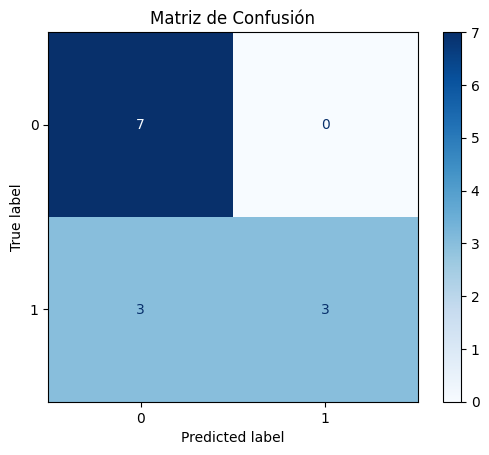

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Librería para cargar las imágenes
import glob

parkings_ocupados = []
parkings_libres = []
etiquetas= []

def tratar_img(img_a_tratar):
    img = cv2.imread(img_a_tratar)
    img_parking_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_parking_gray_inv = cv2.bitwise_not(img_parking_gray)
    img_parking_128x128 = cv2.resize(img_parking_gray_inv, (128,128))
    X_aplanado = img_parking_128x128.reshape(16384)
    X_normalizado = X_aplanado / 255
    return X_normalizado

# Leemos las imágenes de entrenamiento
for img in glob.glob('./images/parking_ocupado/*.png'):
    parkings_ocupados.append(tratar_img(img))
    # Llenamos las etiquetas de 1 (ocupado) por cada foto de parking ocupado
    etiquetas.append(1)

for img in glob.glob('./images/parking_vacio/*.png'):
    parkings_libres.append(tratar_img(img))
    # Llenamos las etiquetas de 0 (libre) por cada foto de parking libre
    etiquetas.append(0)

imagenes_entrenamiento = parkings_ocupados + parkings_libres
# Dividimos el dataset en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(imagenes_entrenamiento, etiquetas, test_size = 0.2, train_size = 0.8, random_state = 42, shuffle=True)
# Creamos el modelo KNN
mi_ia = KNeighborsClassifier(n_neighbors = 3)

# Entrenamos la IA pasándole los datos de entrenamiento (X_train, y_train)
mi_ia.fit(X_train, y_train)

predicciones = mi_ia.predict(X_test)

print(predicciones)

# Dibujamos la matriz
matriz = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()